In [1]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /mnt/c/Users/akky0/Desktop/projects/test_sam/notebooks


In [2]:
!git clone https://github.com/facebookresearch/segment-anything-2.git
%cd {HOME}/segment-anything-2
!pip install -e . -q

Cloning into 'segment-anything-2'...
remote: Enumerating objects: 1070, done.
remote: Total 1070 (delta 0), reused 0 (delta 0), pack-reused 1070 (from 1)
Receiving objects: 100% (1070/1070), 134.70 MiB | 8.75 MiB/s, done.
Resolving deltas: 100% (375/375), done.
Updating files: 100% (569/569), done.
/mnt/c/Users/akky0/Desktop/projects/test_sam/notebooks/segment-anything-2


In [3]:
!pip install -q supervision jupyter_bbox_widget

In [4]:
# 環境変数 HOME を $HOME に置き換え
!$checkpointDir = "$HOME\checkpoints"

# ディレクトリを作成（-Force で既に存在してもエラーにならない）
!New-Item -ItemType Directory -Path $checkpointDir -Force

# ファイルをダウンロード
!Invoke-WebRequest -Uri "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt" -OutFile "$checkpointDir\sam2_hiera_tiny.pt"
!Invoke-WebRequest -Uri "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt" -OutFile "$checkpointDir\sam2_hiera_small.pt"
!Invoke-WebRequest -Uri "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt" -OutFile "$checkpointDir\sam2_hiera_base_plus.pt"
!Invoke-WebRequest -Uri "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt" -OutFile "$checkpointDir\sam2_hiera_large.pt"


/bin/bash: =: command not found
/bin/bash: New-Item: command not found
/bin/bash: Invoke-WebRequest: command not found
/bin/bash: Invoke-WebRequest: command not found
/bin/bash: Invoke-WebRequest: command not found
/bin/bash: Invoke-WebRequest: command not found


In [5]:
!mkdir -p {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -P {HOME}/checkpoints

'wget' �́A�����R�}���h�܂��͊O���R�}���h�A
����\�ȃv���O�����܂��̓o�b�` �t�@�C���Ƃ��ĔF������Ă��܂���B
'wget' �́A�����R�}���h�܂��͊O���R�}���h�A
����\�ȃv���O�����܂��̓o�b�` �t�@�C���Ƃ��ĔF������Ă��܂���B
'wget' �́A�����R�}���h�܂��͊O���R�}���h�A
����\�ȃv���O�����܂��̓o�b�` �t�@�C���Ƃ��ĔF������Ă��܂���B
'wget' �́A�����R�}���h�܂��͊O���R�}���h�A
����\�ȃv���O�����܂��̓o�b�` �t�@�C���Ƃ��ĔF������Ă��܂���B


In [6]:
!mkdir -p {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg -P {HOME}/data

In [12]:
import cv2
import torch
import base64

import numpy as np
import supervision as sv

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [14]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = f"{HOME}/checkpoints/sam2_hiera_large.pt"
CONFIG = "sam2_hiera_l.yaml"

sam2_model = build_sam2(CONFIG, CHECKPOINT, device=DEVICE, apply_postprocessing=False)

In [15]:
mask_generator = SAM2AutomaticMaskGenerator(sam2_model)
     

In [16]:
IMAGE_PATH = f"{HOME}/data/dog.jpeg"

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

sam2_result = mask_generator.generate(image_rgb)

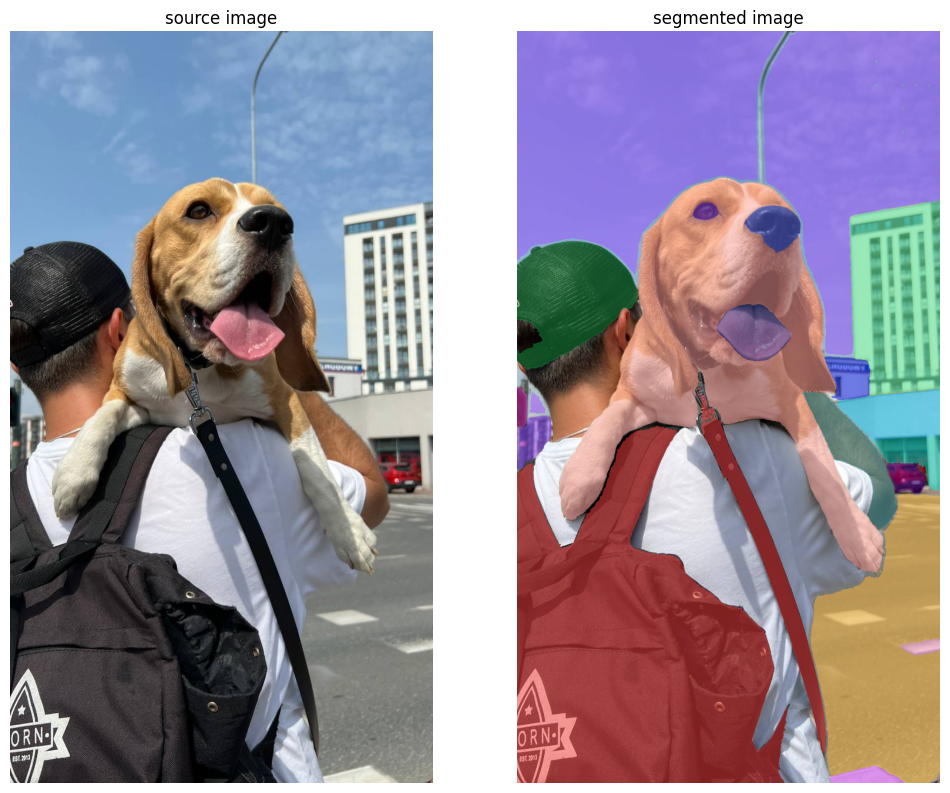

In [17]:

mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
detections = sv.Detections.from_sam(sam_result=sam2_result)

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[image_bgr, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

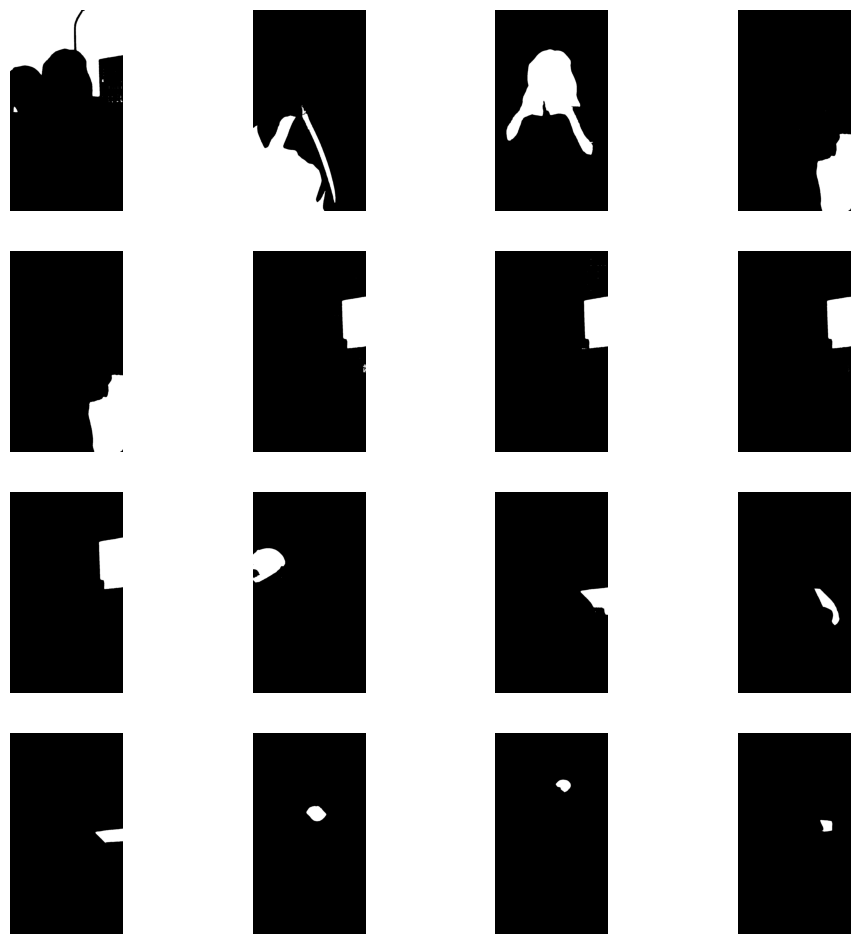

In [18]:
masks = [
    mask['segmentation']
    for mask
    in sorted(sam2_result, key=lambda x: x['area'], reverse=True)
]

sv.plot_images_grid(
    images=masks[:16],
    grid_size=(4, 4),
    size=(12, 12)
)